# THAM SO NCKH

# **XGBOOST, LIGHTGBOOST, CATBOOST, TABNET, NGBOOST, NODE, FT-TRANSFORMER**

In [1]:
!pip install pytorch-tabnet ngboost pytorch-tabular matplotlib-venn seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.4/165.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4118 sha256=6a305b6e2c6f2b278ca605c4a76143fa81c35c585bbc3d2b9d507cddb63e0c07
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
  Attempting uninstall: torchmetrics
    Found existing installation: torchmetrics 1.9.0
    Un

## Cell 1: Tiền xử lý Đa Luồng (Multi-Pipeline Data Dictionary) + Feature Engineering

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")
import joblib
import os

# Tạo thư mục chứa model nếu chưa có
os.makedirs('saved_models', exist_ok=True)

# ==========================================
# 1. CẤU HÌNH HỆ THỐNG & ĐỌC DỮ LIỆU
# ==========================================
RANDOM_SEED = 42
USE_SMOTE_FOR_TREES = False 

df = pd.read_excel('/kaggle/input/datasets/liem2006/attacker-2026-credit-risk/Credit Risk Dataset (1).xlsx')
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Khai báo các cột gốc
numeric_features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
categorical_features = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# CHIA TẬP TRAIN/TEST (Luôn làm trước để chống Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

# ==========================================
# 2. FEATURE ENGINEERING (TẠO ĐẶC TRƯNG MỚI)
# ==========================================
print("⚙️ Đang thực hiện Feature Engineering...")

def engineer_features(X_tr, X_te):
    X_tr = X_tr.copy()
    X_te = X_te.copy()
    
    for df_split in [X_tr, X_te]:
        # 2.1 Cụm rủi ro cá nhân (Financial Ratios)
        df_split['income_per_age'] = df_split['person_income'] / df_split['person_age']
        df_split['emp_stability_ratio'] = df_split['person_emp_length'] / (df_split['person_age'] - 18 + 1e-5)
        df_split['loan_to_emp_length'] = df_split['loan_amnt'] / (df_split['person_emp_length'] + 1)
        df_split['estimated_interest_burden'] = df_split['loan_amnt'] * (df_split['loan_int_rate'] / 100)
        
        # 2.2 Cụm cờ cảnh báo (Risk Flags)
        df_split['is_anomaly_emp'] = (df_split['person_emp_length'] > (df_split['person_age'] - 14)).astype(int)
        df_split['is_extreme_loan'] = (df_split['loan_percent_income'] > 0.5).astype(int)
        
    # 2.3 Cụm Vượt Chuẩn (Chỉ tính Mean trên tập Train để tránh Data Leakage)
    home_income_mean = X_tr.groupby('person_home_ownership')['person_income'].mean()
    X_tr['income_vs_home_mean'] = X_tr['person_income'] / X_tr['person_home_ownership'].map(home_income_mean)
    X_te['income_vs_home_mean'] = X_te['person_income'] / X_te['person_home_ownership'].map(home_income_mean)
    
    grade_loan_mean = X_tr.groupby('loan_grade')['loan_amnt'].mean()
    X_tr['loan_vs_grade_mean'] = X_tr['loan_amnt'] / X_tr['loan_grade'].map(grade_loan_mean)
    X_te['loan_vs_grade_mean'] = X_te['loan_amnt'] / X_te['loan_grade'].map(grade_loan_mean)
    
    # Fillna nếu có giá trị lạ ở tập Test chưa từng xuất hiện ở Train
    X_te['income_vs_home_mean'] = X_te['income_vs_home_mean'].fillna(1.0)
    X_te['loan_vs_grade_mean'] = X_te['loan_vs_grade_mean'].fillna(1.0)
    
    return X_tr, X_te

# Áp dụng hàm xào nấu dữ liệu
X_train, X_test = engineer_features(X_train, X_test)

# Đăng ký các biến mới vào danh sách cột Numerical để đưa qua Pipeline
new_num_cols = [
    'income_per_age', 'emp_stability_ratio', 'loan_to_emp_length', 
    'estimated_interest_burden', 'is_anomaly_emp', 'is_extreme_loan',
    'income_vs_home_mean', 'loan_vs_grade_mean'
]
numeric_features.extend(new_num_cols)

# ==========================================
# 3. XÂY DỰNG TỪ ĐIỂN DỮ LIỆU (DATA DICTIONARY)
# ==========================================
data_dict = {}
print("🔄 Đang thiết lập các phiên bản dữ liệu đưa vào 3 Pipelines...")

# --- LUỒNG 1: STANDARD (OHE + SCALED + SMOTE) ---
preprocessor_standard = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
])
X_train_std = preprocessor_standard.fit_transform(X_train)
X_test_std = preprocessor_standard.transform(X_test)

smote = SMOTE(random_state=RANDOM_SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_std, y_train)

data_dict['standard'] = {
    'X_train': X_train_smote, 'y_train': y_train_smote, 
    'X_test': X_test_std, 'y_test': y_test
}

# --- LUỒNG 2: NATIVE CATEGORICAL ---
preprocessor_native = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), categorical_features)
])
X_train_nat = preprocessor_native.fit_transform(X_train)
X_test_nat = preprocessor_native.transform(X_test)

if USE_SMOTE_FOR_TREES:
    X_train_tree, y_train_tree = smote.fit_resample(X_train_nat, y_train)
else:
    X_train_tree, y_train_tree = X_train_nat, y_train.values

data_dict['native'] = {
    'X_train': X_train_tree, 'y_train': y_train_tree, 
    'X_test': X_test_nat, 'y_test': y_test.values
}

# --- LUỒNG 3: RAW DATAFRAME (CHO DL) ---
train_df_dl = X_train.copy()
train_df_dl['loan_status'] = y_train
test_df_dl = X_test.copy()
test_df_dl['loan_status'] = y_test

# Điền khuyết cơ bản trên Dataframe
for col in numeric_features:
    med = train_df_dl[col].median()
    train_df_dl[col] = train_df_dl[col].fillna(med)
    test_df_dl[col] = test_df_dl[col].fillna(med)
for col in categorical_features:
    mod = train_df_dl[col].mode()[0]
    train_df_dl[col] = train_df_dl[col].fillna(mod).astype(str)
    test_df_dl[col] = test_df_dl[col].fillna(mod).astype(str)

data_dict['dataframe'] = {
    'train': train_df_dl, 'test': test_df_dl,
    'num_cols': numeric_features, 'cat_cols': categorical_features
}

print("✅ Đã chuẩn bị xong 3 luồng dữ liệu riêng biệt kèm Feature Engineering!")

⚙️ Đang thực hiện Feature Engineering...
🔄 Đang thiết lập các phiên bản dữ liệu đưa vào 3 Pipelines...
✅ Đã chuẩn bị xong 3 luồng dữ liệu riêng biệt kèm Feature Engineering!


## Cell 2: Khởi tạo Hệ thống Lõi, Đánh giá & Kho Lưu Xác suất

In [3]:
import time
import gc
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_auc_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

print("⚙️ KHỞI TẠO HỆ THỐNG LÕI, ĐÁNH GIÁ & DỌN DẸP VRAM...")

# 1. Khởi tạo danh sách lưu báo cáo toàn cục
business_reports = []
y_true_benchmark = data_dict['standard']['y_test']  # Nhãn test gốc để chấm điểm

# ==========================================
# KHO LƯU XÁC SUẤT - DÙNG CHO PHÂN TÍCH SAU
# ==========================================
# Dict này lưu xác suất dự đoán của MỌI model ngay khi train xong
# Mục đích: Sau khi del model (giải phóng RAM), vẫn giữ được y_probs để vẽ biểu đồ
all_probs = {}  # Cấu trúc: {'ModelName': np.array([0.1, 0.9, ...])}

# 2. Hàm Đánh Giá Đa Năng (Bao gồm Chẩn đoán Overfit/Underfit và Cắt Ngưỡng)
def evaluate_and_log(model_name, y_train_probs, y_train_true, y_test_probs):
    # --- PHẦN A: CHẨN ĐOÁN OVERFIT / UNDERFIT ---
    train_auc = roc_auc_score(y_train_true, y_train_probs)
    test_auc = roc_auc_score(y_true_benchmark, y_test_probs)
    gap = train_auc - test_auc
    
    print(f"\n📊 CHẨN ĐOÁN SỨC KHỎE [{model_name}]:")
    print(f" - Train AUC     : {train_auc:.4f}")
    print(f" - Test AUC      : {test_auc:.4f}")
    print(f" - Độ lệch (Gap) : {gap:.4f}")
    
    if train_auc < 0.75:
        print(" ⚠️ KẾT LUẬN: UNDERFITTING (Mô hình quá đơn giản, chưa nắm được quy luật nợ xấu).")
    elif gap > 0.05:
        print(" ⚠️ KẾT LUẬN: OVERFITTING (Mô hình học vẹt, thiếu tính tổng quát trên tập khách hàng mới).")
    else:
        print(" ✅ KẾT LUẬN: GOOD FIT! Mô hình cực kỳ ổn định và mạnh mẽ.")

        # --- PHẦN C: LƯU XÁC SUẤT VÀO KHO TOÀN CỤC ---
    all_probs[model_name] = y_test_probs.copy()
    print(f"✅ Đã lưu xác suất dự đoán cho {model_name} vào kho 'all_probs'!")

# Dọn rác khởi động
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


⚙️ KHỞI TẠO HỆ THỐNG LÕI, ĐÁNH GIÁ & DỌN DẸP VRAM...


## Cell 3A: Train XGBoost

In [4]:
import time
import xgboost as xgb
from sklearn.model_selection import train_test_split

name = 'XGBoost'
print(f"🚀 BẮT ĐẦU: {name} (SOTA Config)")
start_time = time.time()

# Data
X_tr_full, y_tr_full = data_dict['standard']['X_train'], data_dict['standard']['y_train']
X_te = data_dict['standard']['X_test']

# Trích xuất 20% dữ liệu làm bia ngắm cho Early Stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_tr_full, y_tr_full, test_size=0.2, random_state=RANDOM_SEED)

# Cấu hình SOTA
model = xgb.XGBClassifier(
    random_state=RANDOM_SEED, 
    eval_metric='auc',
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    early_stopping_rounds=50
)

# Train & Predict
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
y_train_probs = model.predict_proba(X_tr)[:, 1]
y_test_probs = model.predict_proba(X_te)[:, 1]

# 💾 LƯU MÔ HÌNH
model_path = f"saved_models/{name}_model.pkl"
joblib.dump(model, model_path)
print(f"💾 Đã lưu mô hình tại: {model_path}")

# Gọi hàm đánh giá
evaluate_and_log(name, y_train_probs, y_tr, y_test_probs)
print(f"⏱️ Thời gian: {time.time() - start_time:.1f} giây")

del model, X_tr, y_tr, X_val, y_val
gc.collect()

🚀 BẮT ĐẦU: XGBoost (SOTA Config)
💾 Đã lưu mô hình tại: saved_models/XGBoost_model.pkl

📊 CHẨN ĐOÁN SỨC KHỎE [XGBoost]:
 - Train AUC     : 0.9938
 - Test AUC      : 0.9437
 - Độ lệch (Gap) : 0.0502
 ⚠️ KẾT LUẬN: OVERFITTING (Mô hình học vẹt, thiếu tính tổng quát trên tập khách hàng mới).
✅ Đã lưu xác suất dự đoán cho XGBoost vào kho 'all_probs'!
⏱️ Thời gian: 5.4 giây


0

## Cell 3B: Train LightGBM

In [5]:
import lightgbm as lgb

name = 'LightGBM'
print(f"🚀 BẮT ĐẦU: {name}")
start_time = time.time()

X_tr, y_tr = data_dict['native']['X_train'], data_dict['native']['y_train']
X_te = data_dict['native']['X_test']

model = lgb.LGBMClassifier(random_state=RANDOM_SEED, verbose=-1, categorical_feature=list(range(len(numeric_features), len(numeric_features)+len(categorical_features))))
if not USE_SMOTE_FOR_TREES:
    model.set_params(is_unbalance=True)

model.fit(X_tr, y_tr)
y_train_probs = model.predict_proba(X_tr)[:, 1]
y_test_probs = model.predict_proba(X_te)[:, 1]

# 💾 LƯU MÔ HÌNH
model_path = f"saved_models/{name}_model.pkl"
joblib.dump(model, model_path)
print(f"💾 Đã lưu mô hình tại: {model_path}")

evaluate_and_log(name, y_train_probs, y_tr, y_test_probs)
print(f"⏱️ Thời gian: {time.time() - start_time:.1f} giây")

del model, X_tr, y_tr, X_te
gc.collect()

🚀 BẮT ĐẦU: LightGBM
💾 Đã lưu mô hình tại: saved_models/LightGBM_model.pkl

📊 CHẨN ĐOÁN SỨC KHỎE [LightGBM]:
 - Train AUC     : 0.9798
 - Test AUC      : 0.9464
 - Độ lệch (Gap) : 0.0334
 ✅ KẾT LUẬN: GOOD FIT! Mô hình cực kỳ ổn định và mạnh mẽ.
✅ Đã lưu xác suất dự đoán cho LightGBM vào kho 'all_probs'!
⏱️ Thời gian: 0.5 giây


296

## Cell 3C: Train CatBoost

In [6]:
import time
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

name = 'CatBoost'
print(f"🚀 BẮT ĐẦU: {name} (SOTA Config)")
start_time = time.time()

X_tr_full, y_tr_full = data_dict['native']['X_train'], data_dict['native']['y_train']
X_te = data_dict['native']['X_test']

cat_idx = list(range(len(numeric_features), len(numeric_features)+len(categorical_features)))
X_tr_cat_full = np.array(X_tr_full, dtype=object)
X_te_cat = np.array(X_te, dtype=object)
X_tr_cat_full[:, cat_idx] = X_tr_cat_full[:, cat_idx].astype(int).astype(str)
X_te_cat[:, cat_idx] = X_te_cat[:, cat_idx].astype(int).astype(str)

X_tr, X_val, y_tr, y_val = train_test_split(X_tr_cat_full, y_tr_full, test_size=0.2, random_state=RANDOM_SEED)

model = CatBoostClassifier(
    random_state=RANDOM_SEED, 
    verbose=0, 
    cat_features=cat_idx,
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5.0,
    early_stopping_rounds=50,
    eval_metric='AUC'
)

if not USE_SMOTE_FOR_TREES:
    model.set_params(auto_class_weights='Balanced')

model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
y_train_probs = model.predict_proba(X_tr)[:, 1]
y_test_probs = model.predict_proba(X_te_cat)[:, 1]

# 💾 LƯU MÔ HÌNH
model_path = f"saved_models/{name}_model.cbm"
model.save_model(model_path)
print(f"💾 Đã lưu CatBoost tại: {model_path}")

evaluate_and_log(name, y_train_probs, y_tr, y_test_probs)
print(f"⏱️ Thời gian: {time.time() - start_time:.1f} giây")

del model, X_tr, y_tr, X_val, y_val, X_te_cat, X_tr_cat_full
gc.collect()

🚀 BẮT ĐẦU: CatBoost (SOTA Config)
💾 Đã lưu CatBoost tại: saved_models/CatBoost_model.cbm

📊 CHẨN ĐOÁN SỨC KHỎE [CatBoost]:
 - Train AUC     : 0.9782
 - Test AUC      : 0.9447
 - Độ lệch (Gap) : 0.0335
 ✅ KẾT LUẬN: GOOD FIT! Mô hình cực kỳ ổn định và mạnh mẽ.
✅ Đã lưu xác suất dự đoán cho CatBoost vào kho 'all_probs'!
⏱️ Thời gian: 17.8 giây


0

## Cell 3D: Train NGBoost

In [7]:
import time
import joblib
import numpy as np
from ngboost import NGBClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

name = 'NGBoost'
print(f"🚀 BẮT ĐẦU: {name} (SOTA Config)")
start_time = time.time()

X_tr_full, y_tr_full = data_dict['standard']['X_train'], data_dict['standard']['y_train']
X_te = data_dict['standard']['X_test']

X_tr, X_val, y_tr, y_val = train_test_split(X_tr_full, y_tr_full, test_size=0.2, random_state=RANDOM_SEED)

base_learner = DecisionTreeRegressor(criterion='friedman_mse', max_depth=4, random_state=RANDOM_SEED)

model = NGBClassifier(
    Base=base_learner,
    random_state=RANDOM_SEED, 
    n_estimators=1000,
    learning_rate=0.02,
    minibatch_frac=0.8,
    col_sample=0.8,
    verbose=True, 
    verbose_eval=50
)

model.fit(
    X_tr, y_tr, 
    X_val=X_val, Y_val=y_val, 
    early_stopping_rounds=50
)

y_train_probs = model.predict_proba(X_tr)[:, 1]
y_test_probs = model.predict_proba(X_te)[:, 1]

evaluate_and_log(name, y_train_probs, y_tr, y_test_probs)

# 💾 LƯU MÔ HÌNH
model_path = f"saved_models/{name}_model.pkl"
joblib.dump(model, model_path)
print(f"💾 Đã lưu NGBoost tại: {model_path}")

print(f"⏱️ Thời gian: {time.time() - start_time:.1f} giây")

del model, X_tr, y_tr, X_val, y_val, X_te, X_tr_full, y_tr_full
gc.collect()

🚀 BẮT ĐẦU: NGBoost (SOTA Config)
[iter 0] loss=0.6931 val_loss=0.6740 scale=2.0000 norm=4.0000
[iter 50] loss=0.3629 val_loss=0.3690 scale=2.0000 norm=3.1210
[iter 100] loss=0.3092 val_loss=0.3171 scale=1.0000 norm=1.5340
[iter 150] loss=0.2940 val_loss=0.3015 scale=1.0000 norm=1.5355
[iter 200] loss=0.2852 val_loss=0.2935 scale=2.0000 norm=3.0600
[iter 250] loss=0.2802 val_loss=0.2892 scale=1.0000 norm=1.5291
[iter 300] loss=0.2763 val_loss=0.2859 scale=0.5000 norm=0.7669
[iter 350] loss=0.2723 val_loss=0.2817 scale=0.5000 norm=0.7648
[iter 400] loss=0.2697 val_loss=0.2803 scale=1.0000 norm=1.5312
[iter 450] loss=0.2704 val_loss=0.2791 scale=0.5000 norm=0.7679
[iter 500] loss=0.2675 val_loss=0.2780 scale=0.0156 norm=0.0239
[iter 550] loss=0.2683 val_loss=0.2767 scale=0.0156 norm=0.0240
[iter 600] loss=0.2656 val_loss=0.2762 scale=0.5000 norm=0.7666
[iter 650] loss=0.2662 val_loss=0.2753 scale=1.0000 norm=1.5383
[iter 700] loss=0.2614 val_loss=0.2745 scale=0.2500 norm=0.3814
[iter 750]

50

## Cell 3E: Train TabNet

In [8]:
import time
import gc
import numpy as np
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split

name = 'TabNet'
print(f"🚀 BẮT ĐẦU: {name} (SOTA Config)")
start_time = time.time()

X_tr_full = data_dict['standard']['X_train'].astype(np.float32)
y_tr_full = data_dict['standard']['y_train'].astype(np.int64)
X_te = data_dict['standard']['X_test'].astype(np.float32)

X_tr, X_val, y_tr, y_val = train_test_split(X_tr_full, y_tr_full, test_size=0.2, random_state=RANDOM_SEED)

model = TabNetClassifier(
    n_d=16, n_a=16,
    n_steps=4,
    gamma=1.3,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size": 20, "gamma": 0.5},
    mask_type="entmax",
    seed=RANDOM_SEED, 
    verbose=1
)

model.fit(
    X_train=X_tr, y_train=y_tr,
    eval_set=[(X_val, y_val)],
    eval_name=['valid'],
    eval_metric=['auc'],
    max_epochs=200,
    patience=20,
    batch_size=512,
    virtual_batch_size=128
)

y_train_probs = model.predict_proba(X_tr)[:, 1]
y_test_probs = model.predict_proba(X_te)[:, 1]

evaluate_and_log(name, y_train_probs, y_tr, y_test_probs)
print(f"⏱️ Thời gian: {time.time() - start_time:.1f} giây")

# 💾 LƯU MÔ HÌNH
model_path = f"saved_models/{name}_model"
saved_filepath = model.save_model(model_path)
print(f"💾 Đã lưu TabNet tại: {saved_filepath}")

del model, X_tr, y_tr, X_val, y_val, X_te, X_tr_full, y_tr_full
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

🚀 BẮT ĐẦU: TabNet (SOTA Config)
epoch 0  | loss: 0.51556 | valid_auc: 0.87266 |  0:00:04s
epoch 1  | loss: 0.40105 | valid_auc: 0.89308 |  0:00:06s
epoch 2  | loss: 0.37356 | valid_auc: 0.91178 |  0:00:08s
epoch 3  | loss: 0.3506  | valid_auc: 0.91935 |  0:00:11s
epoch 4  | loss: 0.34222 | valid_auc: 0.91528 |  0:00:13s
epoch 5  | loss: 0.33432 | valid_auc: 0.91945 |  0:00:15s
epoch 6  | loss: 0.32922 | valid_auc: 0.91952 |  0:00:17s
epoch 7  | loss: 0.32434 | valid_auc: 0.92324 |  0:00:20s
epoch 8  | loss: 0.32127 | valid_auc: 0.92697 |  0:00:22s
epoch 9  | loss: 0.32245 | valid_auc: 0.9224  |  0:00:24s
epoch 10 | loss: 0.3186  | valid_auc: 0.93224 |  0:00:26s
epoch 11 | loss: 0.31067 | valid_auc: 0.93027 |  0:00:29s
epoch 12 | loss: 0.3118  | valid_auc: 0.9299  |  0:00:31s
epoch 13 | loss: 0.30653 | valid_auc: 0.92833 |  0:00:33s
epoch 14 | loss: 0.30524 | valid_auc: 0.92582 |  0:00:36s
epoch 15 | loss: 0.29964 | valid_auc: 0.93713 |  0:00:38s
epoch 16 | loss: 0.30161 | valid_auc: 0.

## Cell 3F: Train FT-Transformer

In [9]:
from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig

name = 'FT-Transformer'
print(f"🚀 BẮT ĐẦU: {name} (DL Hạng Nặng)")
start_time = time.time()

train_df = data_dict['dataframe']['train']
test_df = data_dict['dataframe']['test']

data_cfg = DataConfig(target=['loan_status'], continuous_cols=numeric_features, categorical_cols=categorical_features)

trainer_cfg = TrainerConfig(
    batch_size=256,
    max_epochs=200,
    early_stopping_patience=20,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    progress_bar="none"
)

opt_cfg = OptimizerConfig(
    optimizer="AdamW",
    optimizer_params={"weight_decay": 1e-4},
    lr_scheduler="ReduceLROnPlateau",
    lr_scheduler_params={"patience": 5, "factor": 0.5}
)

ft_config = FTTransformerConfig(
    task="classification",
    learning_rate=1e-3,
    num_attn_blocks=6,
    input_embed_dim=64,
    num_heads=8,
    attn_dropout=0.2,
    ff_dropout=0.2
)

model = TabularModel(data_config=data_cfg, model_config=ft_config, optimizer_config=opt_cfg, trainer_config=trainer_cfg)
model.fit(train=train_df)

preds_train_df = model.predict(train_df, ret_logits=False)
preds_test_df = model.predict(test_df, ret_logits=False)

prob_cols = [col for col in preds_test_df.columns if 'probability' in col.lower()]
prob_col = sorted(prob_cols)[-1]

y_train_probs = preds_train_df[prob_col].values
y_test_probs = preds_test_df[prob_col].values
y_tr_true = train_df['loan_status'].values

evaluate_and_log(name, y_train_probs, y_tr_true, y_test_probs)
print(f"⏱️ Thời gian: {time.time() - start_time:.1f} giây")

# 💾 LƯU MÔ HÌNH
model_dir = f"saved_models/{name}_model"
model.save_model(model_dir)
print(f"💾 Đã lưu FT-Transformer tại: {model_dir}")

del model, train_df, test_df, preds_train_df, preds_test_df
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

2026-08-03 12:25:25,821 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-08-03 12:25:25,840 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-08-03 12:25:25,884 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-08-03 12:25:25,996 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel


🚀 BẮT ĐẦU: FT-Transformer (DL Hạng Nặng)


2026-08-03 12:25:26,079 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-03 12:25:26,462 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │  1.1 M │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │  3.7 K │ train │     0 │
│ 2 │ _head            │ LinearHead            │    130 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 M                                                                                                
Total estimated model params size (MB): 4.349                                                                      
Modules in train mode: 130                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

2026-08-03 12:28:27,093 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-08-03 12:28:27,094 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model
`weights_only` was not set, defaulting to `False`.



📊 CHẨN ĐOÁN SỨC KHỎE [FT-Transformer]:
 - Train AUC     : 0.9353
 - Test AUC      : 0.9282
 - Độ lệch (Gap) : 0.0072
 ✅ KẾT LUẬN: GOOD FIT! Mô hình cực kỳ ổn định và mạnh mẽ.
✅ Đã lưu xác suất dự đoán cho FT-Transformer vào kho 'all_probs'!
⏱️ Thời gian: 202.4 giây
💾 Đã lưu FT-Transformer tại: saved_models/FT-Transformer_model


## Cell 3G: Train NODE

In [10]:
from pytorch_tabular import TabularModel
from pytorch_tabular.models import NodeConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig

name = 'NODE'
print(f"🚀 BẮT ĐẦU: {name} (DL Hạng Nặng)")
start_time = time.time()

train_df = data_dict['dataframe']['train']
test_df = data_dict['dataframe']['test']

data_cfg = DataConfig(target=['loan_status'], continuous_cols=numeric_features, categorical_cols=categorical_features)

trainer_cfg = TrainerConfig(
    batch_size=256,
    max_epochs=200,
    early_stopping_patience=20,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    progress_bar="none"
)

opt_cfg = OptimizerConfig(
    optimizer="AdamW",
    optimizer_params={"weight_decay": 1e-4},
    lr_scheduler="ReduceLROnPlateau",
    lr_scheduler_params={"patience": 5, "factor": 0.5}
)

node_config = NodeConfig(
    task="classification",
    learning_rate=1e-3, 
    num_layers=4,
    num_trees=1024,
    depth=6
)

model = TabularModel(data_config=data_cfg, model_config=node_config, optimizer_config=opt_cfg, trainer_config=trainer_cfg)
model.fit(train=train_df)

preds_train_df = model.predict(train_df, ret_logits=False)
preds_test_df = model.predict(test_df, ret_logits=False)

prob_cols = [col for col in preds_test_df.columns if 'probability' in col.lower()]
prob_col = sorted(prob_cols)[-1]

y_train_probs = preds_train_df[prob_col].values
y_test_probs = preds_test_df[prob_col].values
y_tr_true = train_df['loan_status'].values

evaluate_and_log(name, y_train_probs, y_tr_true, y_test_probs)
print(f"⏱️ Thời gian: {time.time() - start_time:.1f} giây")

# 💾 LƯU MÔ HÌNH
model_dir = f"saved_models/{name}_model"
model.save_model(model_dir)
print(f"💾 Đã lưu NODE tại: {model_dir}")

del model, train_df, test_df, preds_train_df, preds_test_df
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

2026-08-03 12:28:48,930 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-08-03 12:28:48,947 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-08-03 12:28:48,974 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-08-03 12:28:49,064 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: NODEModel


🚀 BẮT ĐẦU: NODE (DL Hạng Nặng)


2026-08-03 12:28:50,289 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
2026-08-03 12:30:23,553 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-08-03 12:30:23,603 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ NODEBackbone     │  190 M │ train │     0 │
│ 1 │ _embedding_layer │ Embedding1dLayer │    111 │ train │     0 │
│ 2 │ _head            │ Lambda           │      0 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 190 M                                                                                            
Non-trainable params: 3.1 K                                                                                        
Total params: 190 M                                                                                                
Total estimated model params size (MB): 763.179                                                                    
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

2026-08-03 13:48:13,369 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-08-03 13:48:13,376 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model



📊 CHẨN ĐOÁN SỨC KHỎE [NODE]:
 - Train AUC     : 0.9384
 - Test AUC      : 0.9173
 - Độ lệch (Gap) : 0.0211
 ✅ KẾT LUẬN: GOOD FIT! Mô hình cực kỳ ổn định và mạnh mẽ.
✅ Đã lưu xác suất dự đoán cho NODE vào kho 'all_probs'!
⏱️ Thời gian: 9731.9 giây


`weights_only` was not set, defaulting to `False`.


💾 Đã lưu NODE tại: saved_models/NODE_model


## Cell 4: Xuất Dashboard So Sánh (Bảng Kinh doanh)

## BẢNG ĐIỀU KHIỂN CẮT NGƯỠNG TỰ ĐỘNG (THRESHOLD CONFIGURATION)
Chỉ cần chạy Cell này để tính lại các mốc kinh doanh mà **KHÔNG CẦN TRAIN LẠI MODEL**. Bạn tự do sửa các biến `TARGET_PRECISION` và `TARGET_RECALL`.

In [11]:
# ==========================================
# ⚙️ BẢNG ĐIỀU KHIỂN THRESHOLD (THRESHOLD DASHBOARD)
# ==========================================
TARGET_PRECISION = 0.9   # Ngưỡng An toàn mong muốn (Tự do thay đổi)
TARGET_RECALL = 0.9      # Ngưỡng Quét sạch mong muốn (Tự do thay đổi)

business_reports = []

for model_name, p_arr in all_probs.items():
    precisions, recalls, thresholds = precision_recall_curve(y_true_benchmark, p_arr)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    
    # Max F1
    t_f1 = thresholds[np.argmax(f1_scores)]
    
    # Theo Target Precision
    idx_p = np.where(precisions[:-1] >= TARGET_PRECISION)[0]
    t_prec = thresholds[idx_p[0]] if len(idx_p) > 0 else thresholds[np.argmax(precisions[:-1])]
    
    # Theo Target Recall
    idx_r = np.where(recalls[:-1] >= TARGET_RECALL)[0]
    t_rec = thresholds[idx_r[-1]] if len(idx_r) > 0 else thresholds[np.argmax(recalls[:-1])]
    
    choices = [
        ('Cân Bằng (Max F1)', t_f1),
        (f'An Toàn (Prec ≥ {TARGET_PRECISION})', t_prec),
        (f'Quét Sạch (Rec ≥ {TARGET_RECALL})', t_rec)
    ]
    
    for ver_name, t in choices:
        y_pred = (p_arr >= t).astype(int)
        business_reports.append({
            'Model Core': model_name,
            'Phiên bản Kinh doanh': ver_name,
            'Threshold Mở Khóa': t,
            'ROC AUC': roc_auc_score(y_true_benchmark, p_arr),
            'F1 Score': f1_score(y_true_benchmark, y_pred),
            'Precision': precision_score(y_true_benchmark, y_pred, zero_division=0),
            'Recall': recall_score(y_true_benchmark, y_pred, zero_division=0)
        })

# Xuất Báo Cáo
report_df = pd.DataFrame(business_reports).set_index(['Model Core', 'Phiên bản Kinh doanh'])
print("🏆 BẢNG TỔNG HỢP MA TRẬN KINH DOANH CHO CÁC MÔ HÌNH SOTA:")
display(report_df.round(4))
report_df.to_excel('SOTA_Business_Threshold_Report.xlsx')
print("\n✅ Đã lưu báo cáo ra file: SOTA_Business_Threshold_Report.xlsx")


🏆 BẢNG TỔNG HỢP MA TRẬN KINH DOANH CHO CÁC MÔ HÌNH SOTA:


Threshold Mở Khóa  ROC AUC  F1 Score  \
Model Core     Phiên bản Kinh doanh                                          
XGBoost        Cân Bằng (Max F1)                 0.5541   0.9437    0.8286   
               An Toàn (Prec ≥ 0.9)              0.3719   0.9437    0.8205   
               Quét Sạch (Rec ≥ 0.9)             0.1449   0.9437    0.6830   
LightGBM       Cân Bằng (Max F1)                 0.6051   0.9464    0.8333   
               An Toàn (Prec ≥ 0.9)              0.5546   0.9464    0.8269   
               Quét Sạch (Rec ≥ 0.9)             0.2766   0.9464    0.6898   
CatBoost       Cân Bằng (Max F1)                 0.6723   0.9447    0.8356   
               An Toàn (Prec ≥ 0.9)              0.5238   0.9447    0.8275   
               Quét Sạch (Rec ≥ 0.9)             0.2584   0.9447    0.6728   
NGBoost        Cân Bằng (Max F1)                 0.7436   0.9217    0.7976   
               An Toàn (Prec ≥ 0.9)              0.6811   0.9217    0.7901   
               Quét Sạch (Rec ≥ 0.9)             0.2046   0.9217    0.5945   
TabNet         Cân Bằng (Max F1)                 0.8553   0.8933    0.7857   
               An Toàn (Prec ≥ 0.9)              0.7815   0.8933    0.7775   
               Quét Sạch (Rec ≥ 0.9)             0.0312   0.8933    0.5065   
FT-Transformer Cân Bằng (Max F1)                 0.5061   0.9282    0.8160   
               An Toàn (Prec ≥ 0.9)              0.2771   0.9282    0.8009   
               Quét Sạch (Rec ≥ 0.9)             0.1009   0.9282    0.6098   
NODE           Cân Bằng (Max F1)                 0.3850   0.9173    0.8080   
               An Toàn (Prec ≥ 0.9)              0.3640   0.9173    0.8042   
               Quét Sạch (Rec ≥ 0.9)             0.0806   0.9173    0.5837   

                                      Precision  Recall  
Model Core     Phiên bản Kinh doanh                      
XGBoost        Cân Bằng (Max F1)         0.9808  0.7173  
               An Toàn (Prec ≥ 0.9)      0.9001  0.7539  
               Quét Sạch (Rec ≥ 0.9)     0.5503  0.9001  
LightGBM       Cân Bằng (Max F1)         0.9337  0.7525  
               An Toàn (Prec ≥ 0.9)      0.9006  0.7644  
               Quét Sạch (Rec ≥ 0.9)     0.5592  0.9001  
CatBoost       Cân Bằng (Max F1)         0.9783  0.7293  
               An Toàn (Prec ≥ 0.9)      0.9000  0.7658  
               Quét Sạch (Rec ≥ 0.9)     0.5371  0.9001  
NGBoost        Cân Bằng (Max F1)         0.9373  0.6941  
               An Toàn (Prec ≥ 0.9)      0.9002  0.7039  
               Quét Sạch (Rec ≥ 0.9)     0.4438  0.9001  
TabNet         Cân Bằng (Max F1)         0.9438  0.6730  
               An Toàn (Prec ≥ 0.9)      0.9001  0.6842  
               Quét Sạch (Rec ≥ 0.9)     0.3524  0.9001  
FT-Transformer Cân Bằng (Max F1)         0.9718  0.7032  
               An Toàn (Prec ≥ 0.9)      0.9000  0.7215  
               Quét Sạch (Rec ≥ 0.9)     0.4611  0.9001  
NODE           Cân Bằng (Max F1)         0.9147  0.7236  
               An Toàn (Prec ≥ 0.9)      0.9006  0.7264  
               Quét Sạch (Rec ≥ 0.9)     0.4318  0.9001


✅ Đã lưu báo cáo ra file: SOTA_Business_Threshold_Report.xlsx


## Cell 5: Phân tích Phân bổ Dự đoán (Stripplot per Model)

**Mục đích:** Xem xác suất mà mỗi model dự đoán cho Label 0 và Label 1.
- Cột trái (0): Người tốt thực sự
- Cột phải (1): Nợ xấu thực sự
- Vùng hồng mờ: Nợ xấu bị model bỏ lọt (False Negatives)
- Đường đứt đen: Ngưỡng Max F1
- Đường xanh lá: Ngưỡng Quét Sạch (Recall ≥ 0.95)

📊 Đang vẽ phân bố xác suất cho 7 model trong kho...
   Danh sách model: ['XGBoost', 'LightGBM', 'CatBoost', 'NGBoost', 'TabNet', 'FT-Transformer', 'NODE']


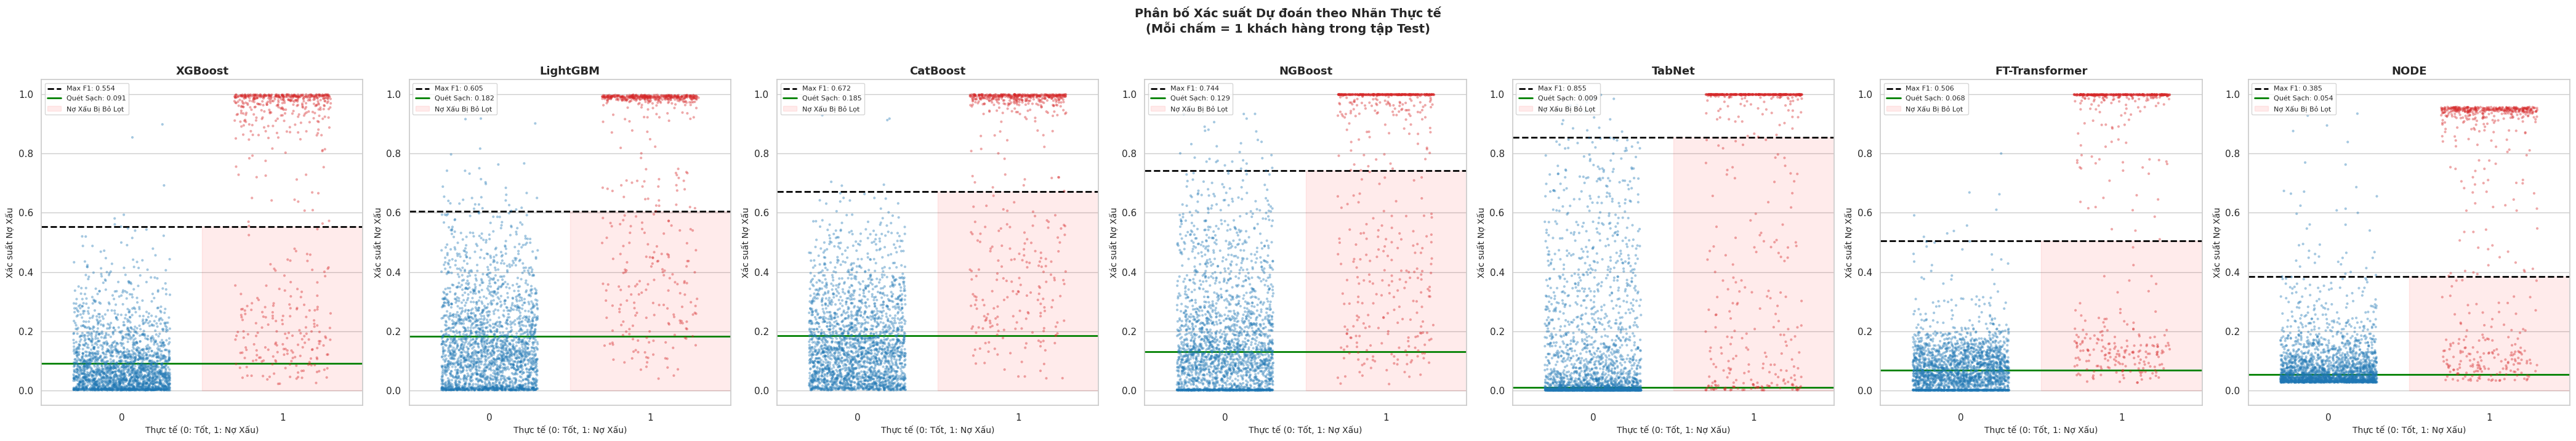

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

print(f"📊 Đang vẽ phân bố xác suất cho {len(all_probs)} model trong kho...")
print(f"   Danh sách model: {list(all_probs.keys())}")

if len(all_probs) == 0:
    print("⚠️ Chưa có xác suất nào! Hãy chạy các cell train model trước.")
else:
    model_names = list(all_probs.keys())
    n_models = len(model_names)
    
    # Lấy mẫu để biểu đồ không bị đặc kịt
    y_true_np = np.array(y_true_benchmark)
    sample_idx = np.random.choice(len(y_true_np), size=min(3000, len(y_true_np)), replace=False)
    y_true_sample = y_true_np[sample_idx]
    
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 7), sharey=False)
    if n_models == 1:
        axes = [axes]
    
    for i, model_name in enumerate(model_names):
        ax = axes[i]
        y_probs = all_probs[model_name]
        y_probs_sample = y_probs[sample_idx]
        
        # Tạo DataFrame cho seaborn
        plot_df = pd.DataFrame({
            'True_Label': y_true_sample,
            'Probability': y_probs_sample
        })
        
        # Vẽ Stripplot
        sns.stripplot(
            data=plot_df, 
            x='True_Label', 
            y='Probability', 
            hue='True_Label', 
            palette={0: '#1f77b4', 1: '#d62728'}, 
            alpha=0.4, 
            jitter=0.3,
            size=3,
            legend=False,
            ax=ax
        )
        
        # Tính ngưỡng từ TOÀN BỘ dữ liệu (không phải sample)
        precisions, recalls, thresh = precision_recall_curve(y_true_np, y_probs)
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
        thresh_f1 = thresh[np.argmax(f1_scores)]
        
        valid_rec_idx = np.where(recalls[:-1] >= 0.95)[0]
        thresh_qs = thresh[valid_rec_idx[-1]] if len(valid_rec_idx) > 0 else thresh[np.argmax(recalls[:-1])]
        
        # Vẽ đường ngưỡng
        ax.axhline(thresh_f1, color='black', linestyle='--', lw=2, label=f'Max F1: {thresh_f1:.3f}')
        ax.axhline(thresh_qs, color='green', linestyle='-', lw=2, label=f'Quét Sạch: {thresh_qs:.3f}')
        
        # Vùng bỏ lọt Nợ Xấu (Label 1 rơi xuống dưới thresh_f1)
        # axvspan theo tọa độ X axis: 0.5 đến 1.5 tương ứng với cột phải (True_Label = 1)
        ax.axhspan(0, thresh_f1, xmin=0.5, xmax=1.0, color='red', alpha=0.08, label='Nợ Xấu Bị Bỏ Lọt')
        
        ax.set_title(f"{model_name}", fontweight='bold', fontsize=13)
        ax.set_xlabel("Thực tế (0: Tốt, 1: Nợ Xấu)", fontsize=10)
        ax.set_ylabel("Xác suất Nợ Xấu", fontsize=10)
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc='upper left', fontsize=8)
    
    plt.suptitle("Phân bố Xác suất Dự đoán theo Nhãn Thực tế\n(Mỗi chấm = 1 khách hàng trong tập Test)", 
                 fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## Cell 6: Phân tích Tương quan Xác suất giữa các Model

**Mục đích:** Xác định liệu các model có "suy nghĩ" độc lập với nhau không.
- Heatmap Spearman: Càng thấp → Càng dễ Ensemble
- Scatter plots: Chấm xa đường chéo → Model bù trừ tốt cho nhau

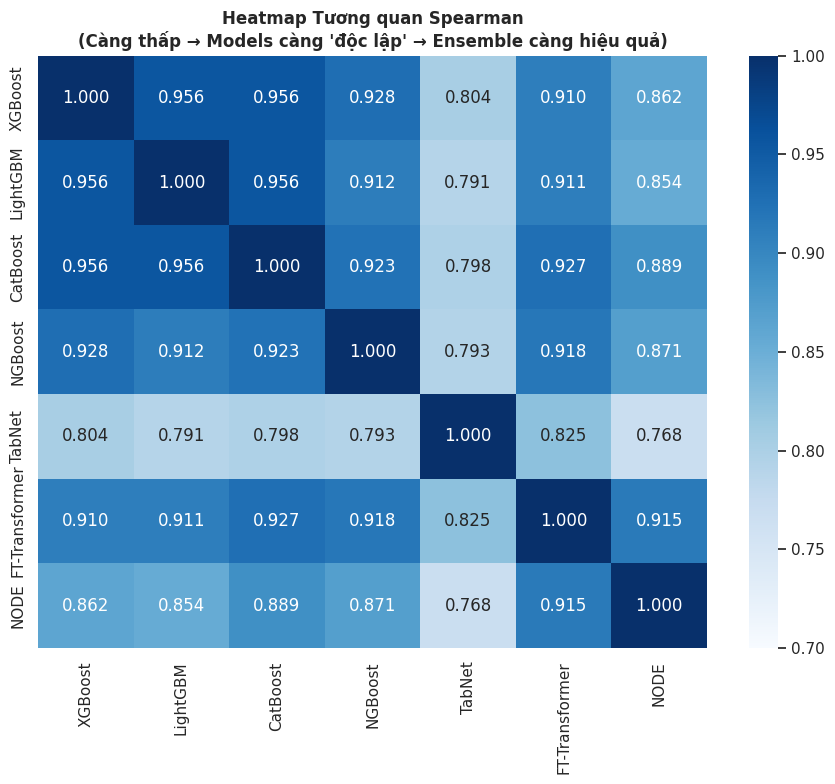

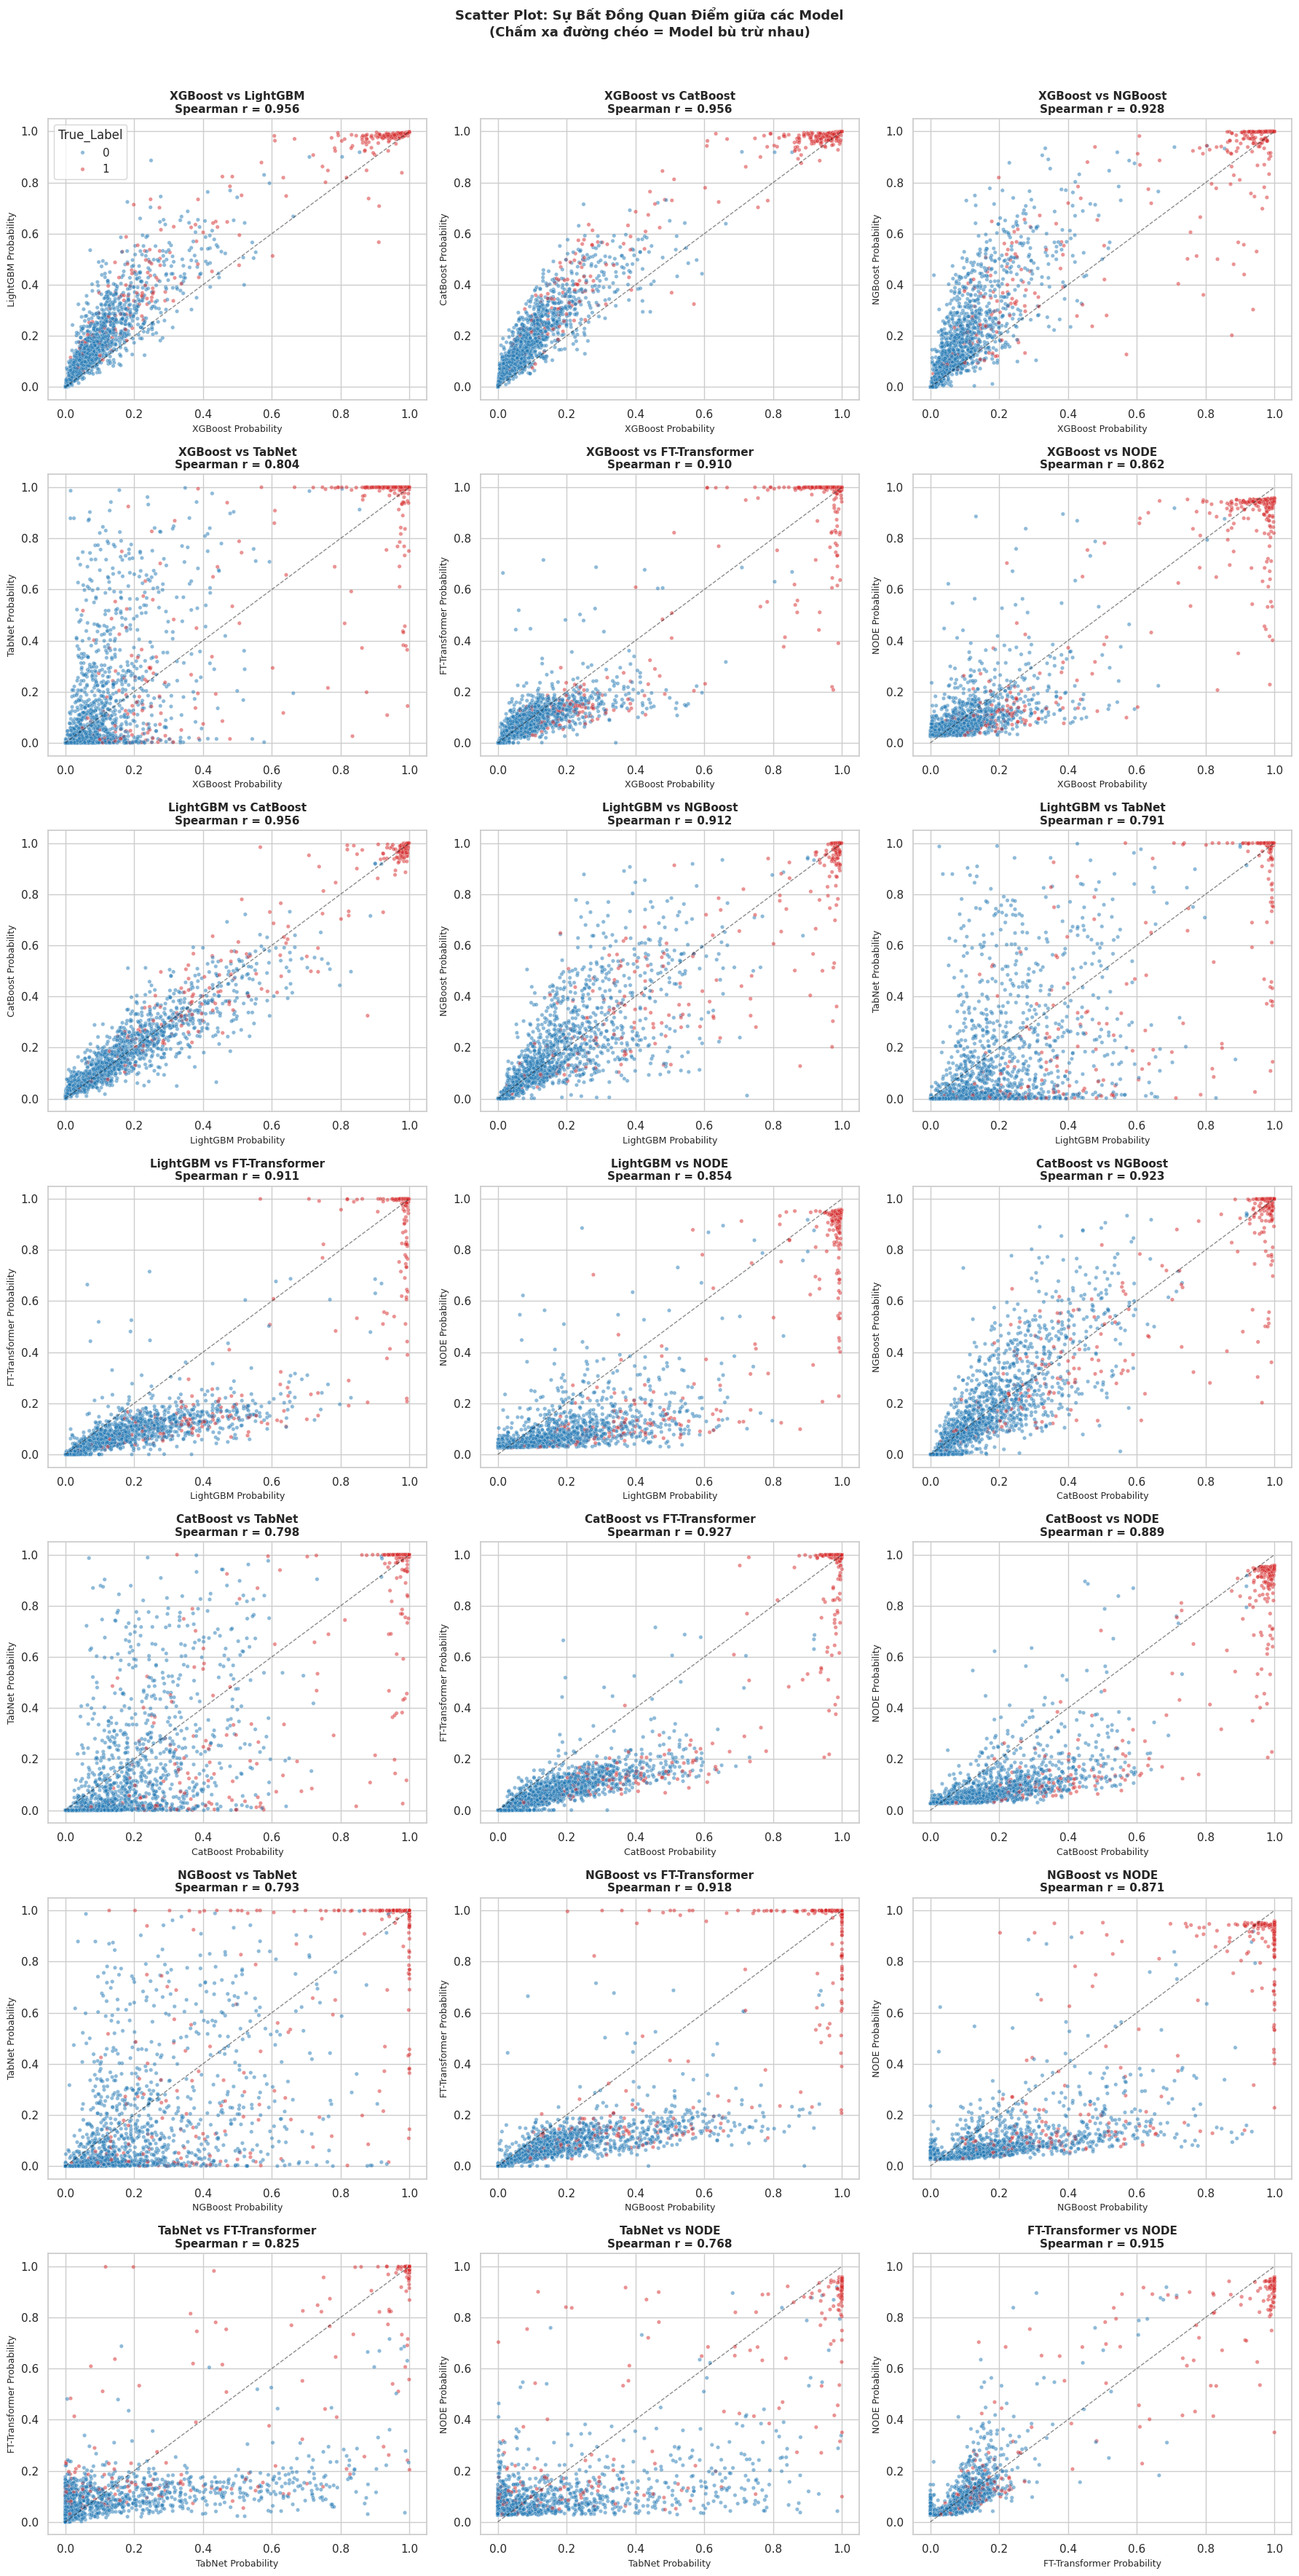

In [13]:
if len(all_probs) < 2:
    print("⚠️ Cần ít nhất 2 model để phân tích tương quan. Hãy chạy thêm các cell train.")
else:
    # Tạo DataFrame xác suất
    df_probs = pd.DataFrame(all_probs)
    df_probs['True_Label'] = np.array(y_true_benchmark)
    
    model_names = [col for col in df_probs.columns if col != 'True_Label']
    n = len(model_names)
    
    # --- HEATMAP TƯƠNG QUAN ---
    fig, axes = plt.subplots(1, 1, figsize=(max(6, n + 2), max(5, n + 1)))
    corr = df_probs[model_names].corr(method='spearman')
    sns.heatmap(corr, annot=True, cmap='Blues', vmin=0.7, vmax=1.0, fmt=".3f", ax=axes, 
                annot_kws={"size": 12})
    axes.set_title("Heatmap Tương quan Spearman\n(Càng thấp → Models càng 'độc lập' → Ensemble càng hiệu quả)",
                   fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # --- SCATTER PLOTS CHO MỌI CẶP MODEL ---
    from itertools import combinations
    pairs = list(combinations(model_names, 2))
    
    if len(pairs) > 0:
        n_pairs = len(pairs)
        n_cols = min(3, n_pairs)
        n_rows = (n_pairs + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
        if n_pairs == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = list(axes)
        else:
            axes = [ax for row in axes for ax in row]
        
        # Lấy mẫu
        sample_idx = np.random.choice(len(df_probs), size=min(2000, len(df_probs)), replace=False)
        sample_df = df_probs.iloc[sample_idx]
        
        for i, (m1, m2) in enumerate(pairs):
            ax = axes[i]
            sns.scatterplot(
                data=sample_df, x=m1, y=m2, 
                hue='True_Label', alpha=0.5, 
                palette={0: '#1f77b4', 1: '#d62728'}, 
                s=15, legend=(i == 0), ax=ax
            )
            ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
            
            spearman_r = corr.loc[m1, m2]
            ax.set_title(f"{m1} vs {m2}\nSpearman r = {spearman_r:.3f}", fontweight='bold', fontsize=11)
            ax.set_xlabel(f"{m1} Probability", fontsize=9)
            ax.set_ylabel(f"{m2} Probability", fontsize=9)
        
        # Ẩn các ô thừa
        for j in range(len(pairs), len(axes)):
            axes[j].set_visible(False)
        
        plt.suptitle("Scatter Plot: Sự Bất Đồng Quan Điểm giữa các Model\n(Chấm xa đường chéo = Model bù trừ nhau)",
                     fontweight='bold', fontsize=13, y=1.01)
        plt.tight_layout()
        plt.show()

## Cell 7: Phân tích Lỗi Giao thoa (Venn Diagram)

**Mục đích:** Xem mỗi model đang bắt nhầm (False Positives) ở những khách hàng nào.
- Chỉ chạy cho tối đa 3 model (giới hạn của Venn 3)
- Số ở vùng giao = Ca bị CẢ 2/3 model đồng loạt bắt nhầm → Không thể cứu vãn bằng Ensemble

🔍 Đang tìm các ca BẮT NHẦM (False Positives) ở ngưỡng Recall ≥ 0.95...

  XGBoost              | Threshold: 0.0907 | Recall: 0.9501 | Precision: 0.4221 | FP: 1850
  LightGBM             | Threshold: 0.1825 | Recall: 0.9501 | Precision: 0.4279 | FP: 1806
  CatBoost             | Threshold: 0.1845 | Recall: 0.9501 | Precision: 0.4297 | FP: 1793
  NGBoost              | Threshold: 0.1294 | Recall: 0.9501 | Precision: 0.3575 | FP: 2428
  TabNet               | Threshold: 0.0094 | Recall: 0.9501 | Precision: 0.3109 | FP: 2994
  FT-Transformer       | Threshold: 0.0685 | Recall: 0.9501 | Precision: 0.3728 | FP: 2273
  NODE                 | Threshold: 0.0540 | Recall: 0.9501 | Precision: 0.3485 | FP: 2526


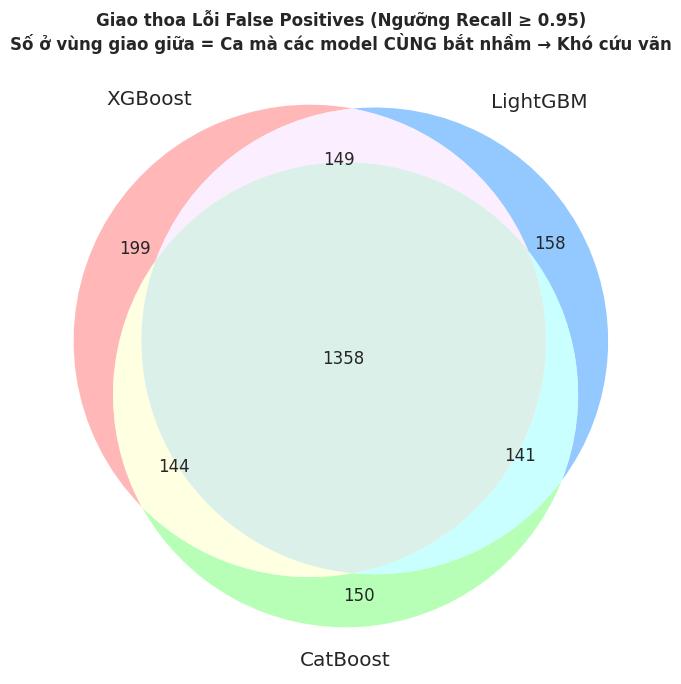


⚠️ Chỉ vẽ Venn cho 3 model đầu: ['XGBoost', 'LightGBM', 'CatBoost'].
   Các model còn lại: ['NGBoost', 'TabNet', 'FT-Transformer', 'NODE']

💡 NHẬN XÉT CHIẾN THUẬT ENSEMBLE:
  - XGBoost và LightGBM đều sai: 1507 ca
  - Chỉ XGBoost sai: 343 ca (m2 có thể sửa được)
  - Chỉ LightGBM sai: 299 ca (m1 có thể sửa được)
  - Cả 3 model đều sai: 1358 ca (KHÔNG thể cứu bằng Voting Ensemble)


In [14]:
from matplotlib_venn import venn2, venn3

if len(all_probs) == 0:
    print("⚠️ Chưa có xác suất nào. Hãy chạy cell train trước.")
else:
    y_true_np = np.array(y_true_benchmark)
    fp_sets = {}
    thresholds_sweep = {}
    
    print("🔍 Đang tìm các ca BẮT NHẦM (False Positives) ở ngưỡng Recall ≥ 0.95...\n")
    
    for model_name, y_probs in all_probs.items():
        precisions, recalls, thresh = precision_recall_curve(y_true_np, y_probs)
        valid_rec_idx = np.where(recalls[:-1] >= 0.95)[0]
        t = thresh[valid_rec_idx[-1]] if len(valid_rec_idx) > 0 else thresh[np.argmax(recalls[:-1])]
        thresholds_sweep[model_name] = t
        
        y_pred = (y_probs >= t).astype(int)
        fps = set(np.where((y_pred == 1) & (y_true_np == 0))[0])
        fp_sets[model_name] = fps
        
        # Tính nhanh metrics tại ngưỡng này
        recall_at_t = recall_score(y_true_np, y_pred, zero_division=0)
        prec_at_t = precision_score(y_true_np, y_pred, zero_division=0)
        print(f"  {model_name:20} | Threshold: {t:.4f} | Recall: {recall_at_t:.4f} | Precision: {prec_at_t:.4f} | FP: {len(fps)}")
    
    model_list = list(fp_sets.keys())
    
    if len(model_list) == 1:
        print("\nChỉ có 1 model, không vẽ Venn được.")
    elif len(model_list) == 2:
        plt.figure(figsize=(7, 6))
        venn2(
            subsets=[fp_sets[model_list[0]], fp_sets[model_list[1]]],
            set_labels=(model_list[0], model_list[1]),
            set_colors=('#ff9999', '#66b3ff'),
            alpha=0.7
        )
        plt.title(f"Giao thoa Lỗi False Positives (Ngưỡng Recall ≥ 0.95)\n{model_list[0]} vs {model_list[1]}",
                  fontweight='bold', fontsize=13)
        plt.show()
    else:
        # Vẽ Venn cho 3 model đầu tiên (nếu có nhiều hơn 3, chọn 3 model cần quan tâm nhất)
        top3 = model_list[:3]
        plt.figure(figsize=(9, 8))
        venn3(
            subsets=[fp_sets[top3[0]], fp_sets[top3[1]], fp_sets[top3[2]]],
            set_labels=(top3[0], top3[1], top3[2]),
            set_colors=('#ff9999', '#66b3ff', '#99ff99'),
            alpha=0.7
        )
        plt.title("Giao thoa Lỗi False Positives (Ngưỡng Recall ≥ 0.95)\n"
                  "Số ở vùng giao giữa = Ca mà các model CÙNG bắt nhầm → Khó cứu vãn",
                  fontweight='bold', fontsize=12)
        plt.show()
        
        if len(model_list) > 3:
            print(f"\n⚠️ Chỉ vẽ Venn cho 3 model đầu: {top3}.")
            print(f"   Các model còn lại: {model_list[3:]}")
    
    # Phân tích tổng hợp
    print("\n" + "="*60)
    print("💡 NHẬN XÉT CHIẾN THUẬT ENSEMBLE:")
    if len(model_list) >= 2:
        m1, m2 = model_list[0], model_list[1]
        common_12 = len(fp_sets[m1] & fp_sets[m2])
        only_m1 = len(fp_sets[m1] - fp_sets[m2])
        only_m2 = len(fp_sets[m2] - fp_sets[m1])
        print(f"  - {m1} và {m2} đều sai: {common_12} ca")
        print(f"  - Chỉ {m1} sai: {only_m1} ca (m2 có thể sửa được)")
        print(f"  - Chỉ {m2} sai: {only_m2} ca (m1 có thể sửa được)")
    
    if len(model_list) >= 3:
        m3 = model_list[2]
        common_all = len(fp_sets[model_list[0]] & fp_sets[model_list[1]] & fp_sets[m3])
        print(f"  - Cả 3 model đều sai: {common_all} ca (KHÔNG thể cứu bằng Voting Ensemble)")